In [ ]:
from pathlib import Path
import shutil
import random

SRC_ROOT = Path("SWOT_IW_Labeled_Dataset")
YOLO_ROOT = Path("yolo_training_data")

TRAIN_RATIO = 0.8
IMAGE_EXTS = {".png", ".jpg", ".jpeg"}

for split in ["train", "val"]:
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

pairs = []

for region_dir in SRC_ROOT.iterdir():
    if not region_dir.is_dir():
        continue

    image_dir = region_dir / "data_images"
    label_dir = region_dir / "bb_labels"

    if not image_dir.exists() or not label_dir.exists():
        continue

    for img_path in image_dir.iterdir():
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue

        label_path = label_dir / f"{img_path.stem}.txt"

        if not label_path.exists():
            print(f"Missing label for {img_path}")
            continue

        pairs.append((region_dir.name, img_path, label_path))

random.seed(42)
random.shuffle(pairs)

split_idx = int(len(pairs) * TRAIN_RATIO)
train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]


def copy_pairs(pairs, split):
    for region_name, img_path, label_path in pairs:
        # Prefix region name to avoid filename collisions
        safe_region = region_name.replace(" ", "_")
        new_stem = f"{safe_region}_{img_path.stem}"

        dst_img = YOLO_ROOT / "images" / split / f"{new_stem}{img_path.suffix.lower()}"
        dst_lbl = YOLO_ROOT / "labels" / split / f"{new_stem}.txt"

        shutil.copy2(img_path, dst_img)
        shutil.copy2(label_path, dst_lbl)


copy_pairs(train_pairs, "train")
copy_pairs(val_pairs, "val")

yaml_path = YOLO_ROOT / "data.yaml"

yaml_path.write_text(
    f"""path: {YOLO_ROOT.resolve()}

train: images/train
val: images/val

names:
  0: internal_wave
"""
)

print(f"Total pairs: {len(pairs)}")
print(f"Train: {len(train_pairs)}")
print(f"Val: {len(val_pairs)}")
print(f"YOLO dataset saved to: {YOLO_ROOT.resolve()}")
print(f"YAML saved to: {yaml_path.resolve()}")

In [ ]:
from ultralytics import YOLO
import torch

print("MPS available:", torch.backends.mps.is_available())

model = YOLO("yolo11n.pt")

results = model.train(
    data="yolo_training_data/data.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    device="mps",
    workers=0,
    project="runs_swot",
    name="yolo11_swot_iw",

    lr0=0.02,   # initial learning rate (default is typically 0.01)
)

MPS available: True
Ultralytics 8.4.60 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M1 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_training_data/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_swot_iw-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,


image 1/1 /Users/aguilarj/projects/swot-yolo/SWOT_IW_Labeled_Dataset/South China Sea one/data_images/SWOT_L2_LR_SSH_Expert_009_256_20240113T061325_20240113T070410_PIC0_01.png: 640x96 2 internal_waves, 16.5ms
Speed: 0.6ms preprocess, 16.5ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 96)


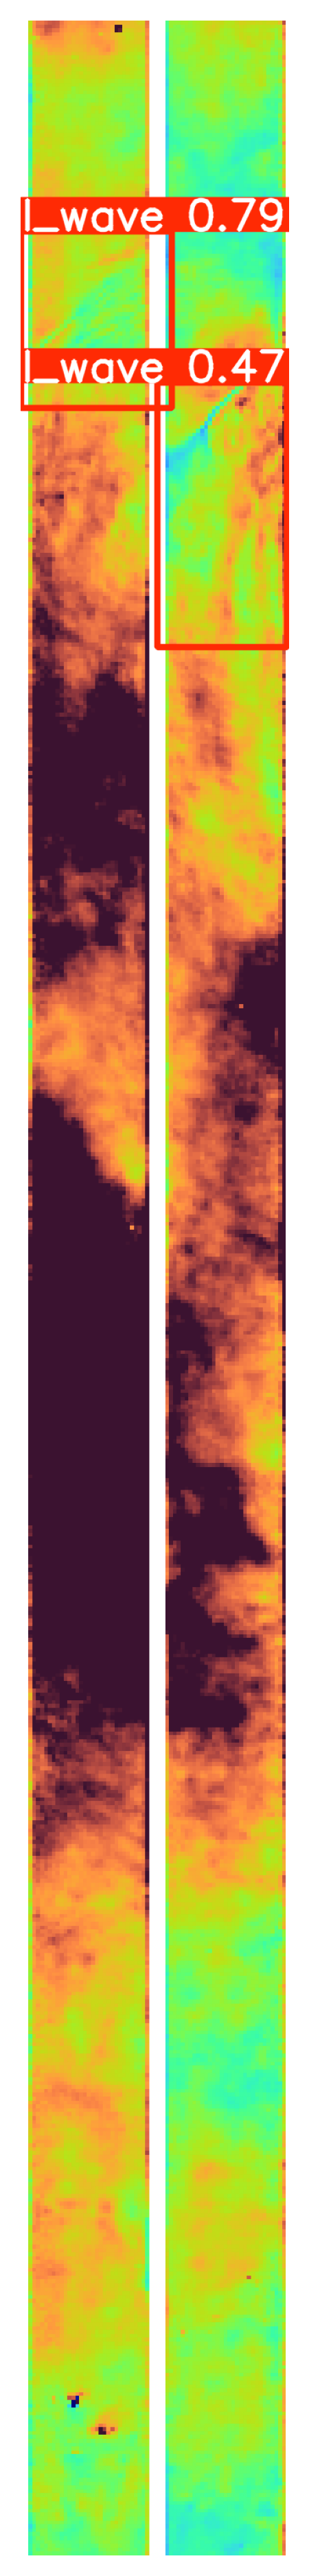

In [7]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load trained model
model = YOLO("runs/detect/runs_swot/yolo11_swot_iw-2/weights/best.pt")

results = model.predict(
    "SWOT_IW_Labeled_Dataset/South China Sea one/data_images/SWOT_L2_LR_SSH_Expert_009_256_20240113T061325_20240113T070410_PIC0_01.png",
    # imgsz=1280  # default is often 640
)

# Get annotated image
annotated = results[0].plot()

plt.figure(figsize=(16, 16), dpi=300)
plt.imshow(annotated)
plt.axis("off")
plt.show()